In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.patches as patches
import json

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0) 


# Split the dataset into a training set and a validation set

In [4]:
path_src = './PAL1999_C6_sample1_slide2/40000x_40000y/full_annot.plk'

In [5]:
with open(path_src, 'rb') as file:
    tmp = pickle.load(file)

In [6]:
tmp

[{'label': 'ind',
  'points': [[96.0632911392405, 336.3544303797468],
   [123.91139240506328, 366.73417721518985]],
  'group_id': None,
  'shape_type': 'circle',
  'flags': {}}]

In [7]:
filename = '59488x_53520y.pkl'

In [8]:
with open(filename, 'rb') as file:
    tmp = pickle.load(file)

In [9]:
tmp = tmp[0]

In [10]:
imName = '3z.png'

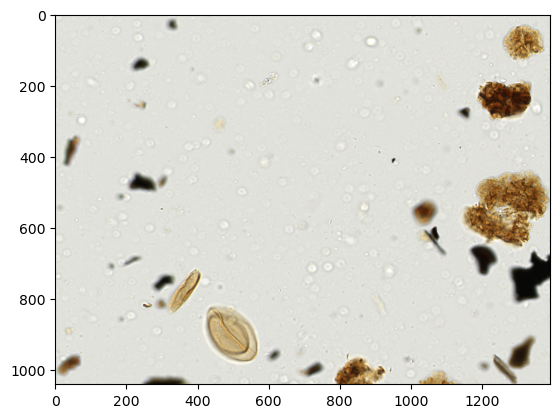

In [11]:
im = skimage.io.imread(imName)
plt.imshow(im)


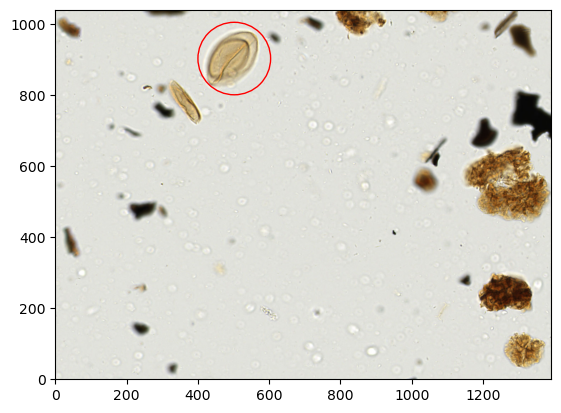

In [12]:
# 1. Create a figure and axes
fig, ax = plt.subplots() #

plt.imshow(im)


# 2. Create a Circle patch object: center (x, y) and radius
center_x = tmp[3]
center_y = tmp[4]
radius = tmp[5]
circle = patches.Circle((center_x, center_y), radius, color='r', fill=False) #

# 3. Add the patch to the axes
ax.add_patch(circle)

# 4. Set axis limits and aspect ratio
ax.set_xlim(0, 5)
ax.set_ylim(0, 6)
ax.axis('equal') # Ensures the circle is not distorted into an oval

# 5. Display the plot
plt.show()


In [13]:
folder_data = './PAL1999_C6_sample1_slide2'
folder_annotation = './PAL1999_C6_sample1_slide2_annotation'

folder_dest = './detection_dataset_v1'

if not Path(folder_dest).is_dir():
    os.mkdir(folder_dest)

In [14]:
list_slices = os.listdir(folder_annotation)

problematicSlices = set()

for cur in list_slices:
    cur_slice = cur.replace('.pkl', '')

    
    save_to_folder = os.path.join(folder_dest, cur_slice)
    if not Path(save_to_folder).is_dir(): os.mkdir(save_to_folder)

    src_path = os.path.join(folder_annotation, cur)
    dst_path = os.path.join(save_to_folder, cur_slice+'_full_annotation.pkl')
    shutil.copyfile(src_path, dst_path)

    tmplist = os.listdir(os.path.join(folder_data, cur_slice))
    for elm in tmplist:
        if '.json' in elm:
            src_path = os.path.join(folder_data, cur_slice, elm)
            dst_path = os.path.join(save_to_folder, elm)
            shutil.copyfile(src_path, dst_path)

            img = elm.replace('.json', '.png')
            src_path = os.path.join(folder_data, cur_slice, img)
            dst_path = os.path.join(save_to_folder, img)
            try:
                shutil.copyfile(src_path, dst_path)
            except:
                problematicSlices.add(cur_slice)            
        if '.plk' in elm:
            tmp = elm.replace('.plk', '.pkl')
            src_path = os.path.join(folder_data, cur_slice, elm)
            dst_path = os.path.join(save_to_folder, tmp)
            shutil.copyfile(src_path, dst_path)
            


    # with open(os.path.join(folder_annotation, cur), 'rb') as file:
    #     annotInfo = pickle.load(file)
    #     if annotInfo:
    #         annotInfo = annotInfo[0]

In [15]:
problematicSlices

{'40000x_50400y', '41392x_45200y'}

In [16]:
for elm in problematicSlices:
    folder_path = os.path.join(folder_dest, elm)
    shutil.rmtree(folder_path)
    